<a href="https://colab.research.google.com/github/Chaotic-Legend/CMP-415-Codes/blob/main/Homework%20%232%3A%20Simple%20Linear%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework #2: Simple Linear Model
#### CMP 415: Machine Learning - Isaac D. Hoyos

This homework assignment aims to build a linear model to describe the trend of height increase for the United Kingdom between 1900 and 1980.

**Please complete this notebook and submit it to Brightspace as a PDF file before Wednesday, February 18th, at 11:59 PM.**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

avergae_height = "average-height-of-men-for-selected-countries.csv"

# Check if the CSV file already exists in the environment.
if not os.path.exists(avergae_height):
    print(f"Please upload the \"average-height-of-men-for-selected-countries.csv\" file...\n")
    while True:
        uploaded = files.upload()

        # Get the name of the uploaded file.
        uploaded_filename = list(uploaded.keys())[0]

        # Check if it's the correct CSV file.
        if uploaded_filename == avergae_height:
            print(f"\n✅ File \"average-height-of-men-for-selected-countries.csv\" has been uploaded successfully!")
            break
        else:
            print(f"\n❌ Error: Please upload the correct \"average-height-of-men-for-selected-countries.csv\" file...\n")
else:
    print(f"Using the uploaded \"average-height-of-men-for-selected-countries.csv\" file.")

# This code loads the uploaded CSV file containing average male heights.
df = pd.read_csv(avergae_height)
print("\n== Avergae Height of Men Dataset ==")
df.head()

Please upload the "average-height-of-men-for-selected-countries.csv" file...



Saving average-height-of-men-for-selected-countries.csv to average-height-of-men-for-selected-countries.csv

✅ File "average-height-of-men-for-selected-countries.csv" has been uploaded successfully!

== Avergae Height of Men Dataset ==


,Entity,Code,Year,Human height
0,Afghanistan,AFG,1870,168.40
1,Afghanistan,AFG,1880,165.69
2,Afghanistan,AFG,1930,166.80
3,Afghanistan,AFG,1990,167.10
4,Afghanistan,AFG,2000,161.40


1. Extract the average height values for **United Kingdom** between 1900 and 1980 from the dataset used in Week 2 notebook.

In [2]:
# This code filters the dataset to include only rows for the United Kingdom between 1900 and 1980.
uk_df = df[
    (df['Entity'] == 'United Kingdom') &
    (df['Year'] >= 1900) &
    (df['Year'] <= 1980)]

# These arrays store the year values and corresponding average height values.
years = uk_df['Year'].values
heights = uk_df['Human height'].values

print("Number of United Kingdom Data Points:", len(years))
uk_df

Number of United Kingdom Data Points: 9


,Entity,Code,Year,Human height
1418,United Kingdom,GBR,1900,169.367
1419,United Kingdom,GBR,1910,170.866
1420,United Kingdom,GBR,1920,171.000
1421,United Kingdom,GBR,1930,173.870
1422,United Kingdom,GBR,1940,174.900
1423,United Kingdom,GBR,1950,176.000
1424,United Kingdom,GBR,1960,176.900
1425,United Kingdom,GBR,1970,177.100
1426,United Kingdom,GBR,1980,176.830


2. Find a linear model (height = m * year + b) that can describe the trend of height increase.
    - The value of `m` should be close to the average height increase.
    - The value of `b` should make the line close to the data points.

In [3]:
# This code fits a linear model of the form height = m * year + b using least squares regression.
m, b = np.polyfit(years, heights, 1)
print(f"Slope (m): {m}")
print(f"\nIntercept (b): {b}")

Slope (m): 0.10413999999999952

Intercept (b): -27.939044444443468


3. Display the model line together with the data points.

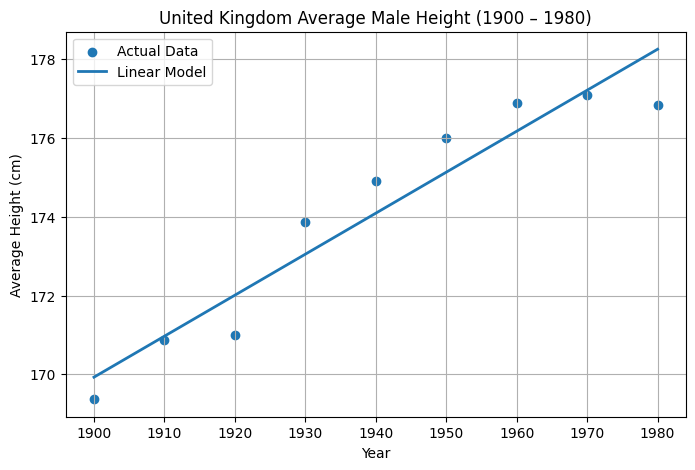

In [4]:
# This code computes the predicted height values using the linear model.
heights_pred = m * years + b

# This code creates a plot showing both the original data points and the fitted linear model.
plt.figure(figsize=(8, 5))
plt.scatter(years, heights, label="Actual Data")
plt.plot(years, heights_pred, label="Linear Model", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Average Height (cm)")
plt.title("United Kingdom Average Male Height (1900 – 1980)")
plt.legend()
plt.grid(True)

plt.show()

4. Compute the Mean Square Error (MSE) of this model.

In [5]:
# This code computes the mean squared error to evaluate the accuracy of the linear model.
mse = np.mean((heights - heights_pred) ** 2)

print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 0.6660565135802544


5. (Optional) Modify `m` and `b` so that the MSE can be reduced.

In [6]:
# This code modifies the slope and intercept slightly to demonstrate how changes affect the mean squared error.
m_try = m * 1.01
b_try = b - 1

# This code computes new predicted values using the modified parameters.
heights_try = m_try * years + b_try

# This code computes the mean squared error for the modified model.
mse_try = np.mean((heights - heights_try) ** 2)

print("Original Mean Squared Error:", mse)
print("\nModified Mean Squared Error:", mse_try)

Original Mean Squared Error: 0.6660565135802544

Modified Mean Squared Error: 1.7078242627430114
